# Hydrogen–brine flow: NeqSim and a pore-network comparison

**Research question:** How do hydrogen, methane and nitrogen properties combine with pore geometry and wettability to control underground storage flow?

This notebook addresses [NeqSim issue #3734](https://github.com/equinor/neqsim/issues/3734), inspired by **Dorhjie and Cheremisin (2024), “Pore-Scale Modeling of Hydrogen-Brine Relative Permeability in Underground Hydrogen Storage,” SPE-219290-MS**, [DOI: 10.2118/219290-MS](https://doi.org/10.2118/219290-MS).

You will calculate gas/brine properties using current NeqSim source, solve drainage and phase conductance in a synthetic 3D throat network, fit a native NeqSim Corey representation, and connect relative permeability to mobility and buoyancy.

**Comparison boundary.** The publisher's indexed abstract was accessible, but the full paper/PDF returned HTTP 403 during preparation. No numerical curves, core geometry, pressure, temperature, salinity or fitted parameters were recovered from it. All numerical inputs below are explicitly **synthetic teaching cases**. The final comparison concerns reported mechanisms and conclusions; no numerical reproduction, digitized data or paper-error metric is claimed.

## 1. Runtime and reproducibility

The default Colab setup installs the Python bridge, checks out the immutable NeqSim `master` revision inspected on 16 September 2026, and builds its Java runtime. It can take several minutes. Run in a fresh runtime, top to bottom.

For an audited local build, `NEQSIM_VALIDATED_RUNTIME` may identify a JSON manifest containing `source_commit`, `source_root`, `jar`, and `jar_sha256`. This path still verifies the revision, JAR hash and loaded Java class location. The stored execution used a new, isolated Python environment and compiled all NeqSim main sources with JDK 17 (`--release 8`). The source snapshot was verified against GitHub blob identities.

In [1]:
import hashlib
import importlib.metadata
import json
import os
from pathlib import Path
import platform
import subprocess
import sys
from urllib.parse import unquote, urlparse

NEQSIM_SOURCE_REF = "87f3c41266ed6ce6dc4ec3879411ae7da59b5eca"
manifest_path = os.environ.get("NEQSIM_VALIDATED_RUNTIME")
if manifest_path:
    runtime = json.loads(Path(manifest_path).read_text())
    assert runtime["source_commit"] == NEQSIM_SOURCE_REF
    source_root = Path(runtime["source_root"]).resolve()
    source_jar = Path(runtime["jar"]).resolve()
    resolved_commit = runtime["source_commit"]
    setup_route = "Audited source build; manifest/hash/class-location checks"
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "neqsim==3.20.0",
         "numpy", "pandas", "matplotlib", "scipy"],
        check=True,
    )
    source_root = Path("hydrogen_brine_runtime/neqsim").resolve()
    if not source_root.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/equinor/neqsim.git", str(source_root)],
            check=True,
            capture_output=True,
        )
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_REF],
        cwd=source_root, check=True, capture_output=True,
    )
    resolved_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=source_root, text=True,
    ).strip()
    assert resolved_commit == NEQSIM_SOURCE_REF
    build = subprocess.run(
        ["bash", "mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true",
         "-Dspotless.skip=true", "package", "dependency:copy-dependencies",
         "-DincludeScope=runtime"],
        cwd=source_root, text=True, capture_output=True,
    )
    (source_root.parent / "build.log").write_text(build.stdout + build.stderr)
    if build.returncode:
        raise RuntimeError("NeqSim build failed; inspect hydrogen_brine_runtime/build.log")
    candidates = sorted(
        path for path in (source_root / "target").glob("neqsim-*.jar")
        if not any(word in path.name for word in ("sources", "javadoc", "tests"))
    )
    source_jar = max(candidates, key=lambda path: path.stat().st_size).resolve()
    runtime = {"jar_sha256": hashlib.sha256(source_jar.read_bytes()).hexdigest()}
    setup_route = "Pinned Git checkout and Maven source build"

jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
assert jar_sha256 == runtime["jar_sha256"]
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
import jpype

if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime to establish an unambiguous Java classpath")
jpype.addClassPath(str(source_jar))
for dependency in sorted((source_root / "target/dependency").glob("*.jar")):
    jpype.addClassPath(str(dependency))
jpype.startJVM(convertStrings=True)
J = jpype.JPackage("neqsim")
probe_class = J.thermo.mixingrule.SoreideWhitsonParameterization.class_
assert J.thermo.mixingrule.SoreideWhitsonParameterization.BURGOYNE_NIELSEN_2026 is not None
loaded_uri = str(probe_class.getProtectionDomain().getCodeSource().getLocation().toURI())
assert Path(unquote(urlparse(loaded_uri).path)).resolve() == source_jar
provenance = {
    "neqsim_source_commit": resolved_commit,
    "jar_sha256": jar_sha256,
    "loaded_java_class": str(probe_class.getName()),
    "loaded_uri": loaded_uri,
    "python": platform.python_version(),
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python_bridge": importlib.metadata.version("neqsim"),
    "setup_route": setup_route,
}
print(json.dumps(provenance, indent=2))

{
  "neqsim_source_commit": "87f3c41266ed6ce6dc4ec3879411ae7da59b5eca",
  "jar_sha256": "5a81a8bc6e035898acf28c53a9fc12147dfa8b33efa92ae964e57cd1743e34dc",
  "loaded_java_class": "neqsim.thermo.mixingrule.SoreideWhitsonParameterization",
  "loaded_uri": "file:/workspace/scratch/ae2708680125/runtime/neqsim-source/target/neqsim-verified.jar",
  "python": "3.12.14",
  "java": "17.0.20",
  "python_bridge": "3.20.0",
  "setup_route": "Audited source build; manifest/hash/class-location checks"
}


In [2]:
import heapq
import itertools

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.sparse.linalg import spsolve
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 10,
})
GASES = ["hydrogen", "methane", "nitrogen"]
COLORS = dict(zip(GASES, ["#008b95", "#d87925", "#7458a6"]))
TEMPERATURE_K = 323.15
PRESSURE_BARA = 100.0
WATER_MOLAR_MASS = 0.01801528
results_directory = Path("hydrogen_brine_results")
results_directory.mkdir(exist_ok=True)
print("Synthetic reference: 323.15 K, 100 bara, 1 mol NaCl per kg feed water")

Synthetic reference: 323.15 K, 100 bara, 1 mol NaCl per kg feed water


## 2. Choose a model for each physical question

| Quantity | NeqSim calculation | Scope |
|---|---|---|
| Dissolved gas | `SystemSoreideWhitson`, mixing rule **11**, `BURGOYNE_NIELSEN_2026` | Gas–water equilibrium with implicit salinity; not ionic speciation |
| Dry gas density / viscosity | SRK stream; Muzny viscosity for pure hydrogen, default PFCT for CH4/N2 | Dry-gas approximation for transport |
| Brine density / viscosity | Explicit neutral NaCl + water, `SALT_WATER` physical properties | Separate empirical transport calculation; not a salt VLE prediction |
| Electrolyte audit | `SystemElectrolyteCPAstatoil` / `SystemFurstElectrolyteEos` | Diagnostic comparison; no experimental qualification claimed |
| Relative permeability | Python network; native NeqSim Corey fit | Depends on geometry and occupancy, not on EOS alone |
| Interfacial tension and contact angle | Explicit user inputs | No validated H2/brine/rock correlation is inferred here |

The Søreide–Whitson hydrogen option is documented in [NeqSim's model guide](https://github.com/equinor/neqsim/blob/87f3c41266ed6ce6dc4ec3879411ae7da59b5eca/docs/thermo/SoreideWhitsonModel.md). It implements the 2026 Burgoyne–Nielsen parameterization; it is an extension used in this notebook, not the 2024 paper's thermodynamic model.

**Salinity basis:** feed water is 1 kg/s. Thus a salt flow of 1 mol/s corresponds to 1 mol/kg feed water. The implicit salt is not a chemical component and is not included in the SW component balance. We report the model's final aqueous salinity separately. Neutral NaCl is used only in the independent transport calculation; no ion dissociation or precipitation is computed there.

In [3]:
def component_closure(fluid, feed):
    errors = []
    for component, inlet_moles in feed.items():
        outlet_moles = sum(
            fluid.getPhase(index).getComponent(component).getNumberOfMolesInPhase()
            for index in range(fluid.getNumberOfPhases())
        )
        errors.append(abs(outlet_moles - inlet_moles) / inlet_moles)
    return max(errors)


def gas_brine_flash(gas, pressure_bara, salt_molality, temperature_k=TEMPERATURE_K):
    feed = {gas: 10.0, "water": 1.0 / WATER_MOLAR_MASS}
    fluid = J.thermo.system.SystemSoreideWhitson(temperature_k, pressure_bara)
    for component, amount in feed.items():
        fluid.addComponent(component, amount)
    fluid.setSalinity(salt_molality, "mole/sec")
    fluid.init(0)
    fluid.setMixingRule(11)
    fluid.setSoreideWhitsonParameterization("BURGOYNE_NIELSEN_2026")
    fluid.setMultiPhaseCheck(True)
    fluid.init(0)
    fluid.init(1)
    J.thermodynamicoperations.ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    assert fluid.hasPhaseType("gas") and fluid.hasPhaseType("aqueous")
    aqueous = fluid.getPhase("aqueous")
    gas_phase = fluid.getPhase("gas")
    water_kg = aqueous.getComponent("water").getNumberOfMolesInPhase() * WATER_MOLAR_MASS
    dissolved_moles = aqueous.getComponent(gas).getNumberOfMolesInPhase()
    fugacity_residual = max(
        abs(np.log(
            gas_phase.getComponent(component).getx()
            * gas_phase.getComponent(component).getFugacityCoefficient()
            / (aqueous.getComponent(component).getx()
               * aqueous.getComponent(component).getFugacityCoefficient())
        ))
        for component in feed
    )
    row = {
        "gas": gas,
        "P_bara": pressure_bara,
        "salt_feed_mol_kg": salt_molality,
        "salt_model_mol_kg": aqueous.getSalinityConcentration(),
        "dissolved_mol_kg_water": dissolved_moles / water_kg,
        "water_in_gas_ppm_mol": gas_phase.getComponent("water").getx() * 1e6,
        "component_error": component_closure(fluid, feed),
        "log_fugacity_error": fugacity_residual,
    }
    return fluid, row


flash_rows = []
for gas, pressure, salinity in itertools.product(GASES, [20., 50., 100., 150., 200.], [0., 1., 3.]):
    _, row = gas_brine_flash(gas, pressure, salinity)
    flash_rows.append(row)
flash_results = pd.DataFrame(flash_rows)
assert flash_results["component_error"].max() < 1e-8
assert flash_results["log_fugacity_error"].max() < 1e-6
reference = flash_results.query("P_bara == 100 and salt_feed_mol_kg == 1")
display(reference.drop(columns=["component_error", "log_fugacity_error"]).round(6))
print("45 accepted flashes; maximum relative component error:",
      f"{flash_results.component_error.max():.3e}")
print("Maximum interphase log-fugacity residual:",
      f"{flash_results.log_fugacity_error.max():.3e}")

45 accepted flashes; maximum relative component error: 2.380e-12
Maximum interphase log-fugacity residual: 2.859e-12


,gas,P_bara,salt_feed_mol_kg,salt_model_mol_kg,dissolved_mol_kg_water,water_in_gas_ppm_mol
7,hydrogen,100.0,1.0,1.000147,0.063078,1440.474375
22,methane,100.0,1.0,0.999319,0.062444,1699.396955
37,nitrogen,100.0,1.0,0.999331,0.034588,1577.764353


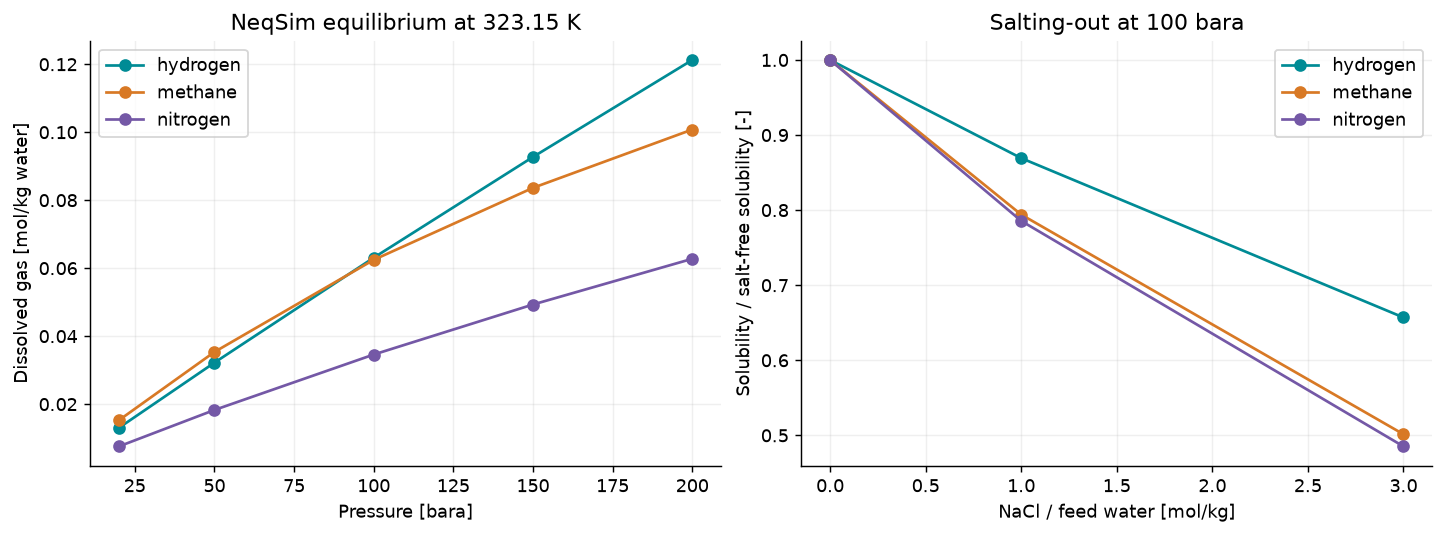

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for gas in GASES:
    pressure_curve = flash_results.query("gas == @gas and salt_feed_mol_kg == 1")
    salinity_curve = flash_results.query("gas == @gas and P_bara == 100")
    axes[0].plot(pressure_curve.P_bara, pressure_curve.dissolved_mol_kg_water,
                 "o-", color=COLORS[gas], label=gas)
    normalized = salinity_curve.dissolved_mol_kg_water.to_numpy()
    axes[1].plot(salinity_curve.salt_feed_mol_kg, normalized / normalized[0],
                 "o-", color=COLORS[gas], label=gas)
axes[0].set(xlabel="Pressure [bara]", ylabel="Dissolved gas [mol/kg water]",
            title="NeqSim equilibrium at 323.15 K")
axes[1].set(xlabel="NaCl / feed water [mol/kg]", ylabel="Solubility / salt-free solubility [-]",
            title="Salting-out at 100 bara")
for axis in axes:
    axis.legend()
plt.show()

Increasing pressure raises dissolved-gas loading in this range. Salinity reduces it in the selected parameterization. These are equilibrium predictions: the network model below does not simulate dissolution kinetics, diffusion or Ostwald ripening.

For transport, do not treat the density of an implicit-salinity SW aqueous phase as a complete brine-density correlation. Also avoid assigning the pure-hydrogen Muzny correlation to a gas mixture. The following dry-gas streams and explicit brine transport system separate these assumptions.

In [5]:
def dry_gas_stream(gas):
    fluid = J.thermo.system.SystemSrkEos(TEMPERATURE_K, PRESSURE_BARA)
    fluid.addComponent(gas, 1.0)
    fluid.setMixingRule(2)
    stream = J.process.equipment.stream.Stream(gas + " dry storage gas", fluid)
    stream.run()
    if gas == "hydrogen":
        stream.getFluid().getPhase("gas").getPhysicalProperties().setViscosityModel("Muzny")
    stream.getFluid().initProperties()
    return stream


def brine_transport(salinity):
    fluid = J.thermo.system.SystemSrkEos(TEMPERATURE_K, PRESSURE_BARA)
    fluid.addComponent("water", 1.0 / WATER_MOLAR_MASS)
    fluid.addComponent("NaCl", salinity)
    fluid.setMixingRule(2)
    J.thermodynamicoperations.ThermodynamicOperations(fluid).TPflash()
    assert fluid.getNumberOfPhases() == 1
    fluid.setPhysicalPropertyModel(J.physicalproperties.system.PhysicalPropertyModel.SALT_WATER)
    fluid.initProperties()
    phase = fluid.getPhase(0)
    return {
        "salt_mol_kg": salinity,
        "density_kg_m3": phase.getDensity("kg/m3"),
        "viscosity_Pa_s": phase.getViscosity("kg/msec"),
    }


dry_streams = {gas: dry_gas_stream(gas) for gas in GASES}
transport_rows = []
for gas, stream in dry_streams.items():
    phase = stream.getFluid().getPhase("gas")
    transport_rows.append({
        "gas": gas,
        "density_kg_m3": phase.getDensity("kg/m3"),
        "viscosity_uPa_s": phase.getViscosity("kg/msec") * 1e6,
    })
gas_transport = pd.DataFrame(transport_rows).set_index("gas")
brine_properties = pd.DataFrame([brine_transport(salinity) for salinity in [0., 1., 3.]])
assert gas_transport.density_kg_m3.between(1, 200).all()
assert gas_transport.viscosity_uPa_s.between(5, 40).all()
assert brine_properties.density_kg_m3.between(950, 1200).all()
assert brine_properties.viscosity_Pa_s.between(0.0003, 0.002).all()
display(gas_transport.round(4))
display(brine_properties.assign(viscosity_mPa_s=brine_properties.viscosity_Pa_s * 1e3)
        .drop(columns="viscosity_Pa_s").round(5))

,density_kg_m3,viscosity_uPa_s
gas,,
hydrogen,7.0921,9.5975
methane,65.7507,14.2801
nitrogen,101.5664,21.2781


,salt_mol_kg,density_kg_m3,viscosity_mPa_s
0,0.0,992.30909,0.54699
1,1.0,1030.18606,0.60625
2,3.0,1098.17452,0.75464


### Electrolyte model audit

The issue suggests two electrolyte models. We test both with explicit, equal Na+ and Cl− inventories (1 mol/s each), 1 kg/s water and 10 mol/s H2. This neutral-salt case omits chemical speciation and water dissociation. Mixing rules are 10 for electrolyte CPA and 4 for Fürst.

The **Fürst result is rejected for use in the flow study** if it lacks a credible hydrogen gas phase. Its output is retained as a diagnostic, tracked in [NeqSim #3736](https://github.com/equinor/neqsim/issues/3736). A converged flash is not sufficient evidence of a physically suitable model. Agreement between CPA and SW is also not experimental validation.

In [6]:
audit_rows = []
for model_name, mixing_rule in [
    ("SystemElectrolyteCPAstatoil", 10),
    ("SystemFurstElectrolyteEos", 4),
]:
    fluid = getattr(J.thermo.system, model_name)(TEMPERATURE_K, PRESSURE_BARA)
    feed = {"hydrogen": 10.0, "water": 1.0 / WATER_MOLAR_MASS, "Na+": 1.0, "Cl-": 1.0}
    for component, amount in feed.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule(mixing_rule)
    fluid.setMultiPhaseCheck(True)
    fluid.init(0)
    fluid.init(1)
    J.thermodynamicoperations.ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    for index in range(fluid.getNumberOfPhases()):
        phase = fluid.getPhase(index)
        charge = phase.getComponent("Na+").getx() - phase.getComponent("Cl-").getx()
        audit_rows.append({
            "model": model_name.replace("System", ""),
            "phase": str(phase.getPhaseTypeName()),
            "density_kg_m3": phase.getDensity("kg/m3"),
            "H2_mole_fraction": phase.getComponent("hydrogen").getx(),
            "charge_mole_fraction": charge,
            "component_error": component_closure(fluid, feed),
        })
audit = pd.DataFrame(audit_rows)
display(audit.round(8))
print("Fürst is diagnostic only; none of its properties enters the accepted network results.")

Fürst is diagnostic only; none of its properties enters the accepted network results.


,model,phase,density_kg_m3,H2_mole_fraction,charge_mole_fraction,component_error
0,ElectrolyteCPAstatoil,gas,7.203144,0.998649,0.0,0.0
1,ElectrolyteCPAstatoil,aqueous,1003.813679,0.001120,0.0,0.0
2,FurstElectrolyteEos,oil,92.195816,0.999999,0.0,0.0
3,FurstElectrolyteEos,aqueous,1023.167269,0.000007,0.0,0.0


## 3. A transparent pore-network model

The synthetic network has cubic connectivity, lognormal cylindrical throat radii, fixed throat length, and zero-volume junctions. Saturation is **throat-volume weighted**. Inlet and outlet faces are normal to the x direction. The network is initially water-filled; gas invades from the inlet under slowly increasing capillary pressure.

For water-wet contact angles measured through brine:

$$P_{e,j}=\frac{2\sigma\cos\theta_j}{r_j}$$

Here entry pressure $P_{e,j}$ is in Pa, interfacial tension $\sigma$ in N/m, contact angle $\theta_j$ in radians, and throat radius $r_j$ in m. An accessible throat invades when the applied capillary pressure exceeds its threshold. A minimax path calculation accounts for inlet accessibility.

At a frozen occupancy, single-phase flow follows Hagen–Poiseuille conductance and nodal conservation:

$$g_j=\frac{\pi r_j^4}{8\mu\ell_j},\qquad \sum_j g_{ij}(p_i-p_j)=0$$

Conductance is in m³/(Pa·s), viscosity $\mu$ in Pa·s, length $\ell_j$ in m, and nodal pressure $p_i$ in Pa. Only clusters connecting both boundaries transmit flow. Isolated clusters carry zero through-flow; no artificial leakage conductance is added.

$$k_{r,\alpha}=\frac{Q_{\alpha}(\mu_\mathrm{ref},\Delta p)}{Q_\mathrm{all}(\mu_\mathrm{ref},\Delta p)}$$

The same reference viscosity and pressure drop are used in numerator and denominator, so relative permeability is dimensionless. This simplified drainage solver omits corner films, snap-off, contact-angle hysteresis, explicit pore bodies, residual trapping and dynamic menisci. Its all-gas endpoint cannot validate the paper's residual-saturation conclusions.

In [7]:
def make_network(size=7, seed=3734, radius_spread=0.45, transverse_retention=1.0):
    rng = np.random.default_rng(seed)
    coordinates = np.array(list(itertools.product(range(size), repeat=3)), dtype=float)
    lookup = {tuple(point.astype(int)): index for index, point in enumerate(coordinates)}
    edges = []
    for point, index in lookup.items():
        for direction in range(3):
            neighbor = list(point)
            neighbor[direction] += 1
            if neighbor[direction] >= size:
                continue
            edges.append((index, lookup[tuple(neighbor)]))
    edges = np.asarray(edges, dtype=int)
    radii = np.clip(rng.lognormal(np.log(12e-6), radius_spread, len(edges)), 3e-6, 35e-6)
    # Generate the complete geometry before thinning so retained throats keep their radii.
    first, second = edges.T
    transverse = coordinates[first, 0] == coordinates[second, 0]
    retained = ~transverse | (rng.random(len(edges)) <= transverse_retention)
    edges = edges[retained]
    radii = radii[retained]
    spacing = 100e-6
    return {
        "coordinates": coordinates,
        "edges": edges,
        "radii": radii,
        "lengths": np.full(len(edges), spacing),
        "inlet": np.flatnonzero(coordinates[:, 0] == 0),
        "outlet": np.flatnonzero(coordinates[:, 0] == size - 1),
        "sample_length": (size - 1) * spacing,
        "sample_area": (size * spacing) ** 2,
    }


def hydraulic_flow(network, occupied, viscosity=1.0, pressure_drop=1.0):
    edges = network["edges"][occupied]
    count = len(network["coordinates"])
    if len(edges) == 0:
        return 0.0, 0.0
    radii = network["radii"][occupied]
    lengths = network["lengths"][occupied]
    conductances = np.pi * radii**4 / (8.0 * viscosity * lengths)
    scale = conductances.max()
    weights = conductances / scale
    first, second = edges.T
    graph = coo_matrix((np.ones(2 * len(edges)),
                        (np.r_[first, second], np.r_[second, first])), shape=(count, count))
    _, labels = connected_components(graph, directed=False)
    spanning_labels = np.intersect1d(labels[network["inlet"]], labels[network["outlet"]])
    active = np.isin(labels, spanning_labels)
    if not active.any():
        return 0.0, 0.0
    matrix = coo_matrix(
        (np.r_[weights, weights, -weights, -weights],
         (np.r_[first, second, first, second], np.r_[first, second, second, first])),
        shape=(count, count),
    ).tocsr()
    fixed = np.zeros(count, dtype=bool)
    fixed[network["inlet"]] = True
    fixed[network["outlet"]] = True
    internal = np.flatnonzero(active & ~fixed)
    boundary = np.flatnonzero(active & fixed)
    pressure = np.zeros(count)
    pressure[network["inlet"]] = pressure_drop
    if len(internal):
        pressure[internal] = spsolve(
            matrix[internal][:, internal],
            -matrix[internal][:, boundary] @ pressure[boundary],
        )
    nodal_flow = matrix @ pressure * scale
    inlet_flow = nodal_flow[network["inlet"][active[network["inlet"]]]].sum()
    outlet_flow = -nodal_flow[network["outlet"][active[network["outlet"]]]].sum()
    balance = abs(inlet_flow - outlet_flow) / max(abs(inlet_flow), 1e-300)
    return float(inlet_flow), float(balance)


def invasion_thresholds(network, angles_deg, sigma_N_m=0.065):
    assert sigma_N_m > 0 and np.all((angles_deg >= 0) & (angles_deg < 90))
    entry = 2 * sigma_N_m * np.cos(np.deg2rad(angles_deg)) / network["radii"]
    adjacency = [[] for _ in network["coordinates"]]
    for edge_index, (first, second) in enumerate(network["edges"]):
        adjacency[first].append((second, edge_index))
        adjacency[second].append((first, edge_index))
    distance = np.full(len(adjacency), np.inf)
    heap = []
    for node in network["inlet"]:
        distance[node] = 0.0
        heapq.heappush(heap, (0.0, node))
    while heap:
        barrier, node = heapq.heappop(heap)
        if barrier > distance[node]:
            continue
        for neighbor, edge_index in adjacency[node]:
            candidate = max(barrier, entry[edge_index])
            if candidate < distance[neighbor]:
                distance[neighbor] = candidate
                heapq.heappush(heap, (candidate, neighbor))
    first, second = network["edges"].T
    return np.maximum(entry, np.minimum(distance[first], distance[second]))


def drainage(network, angles_deg, sigma_N_m=0.065, samples=61):
    thresholds = invasion_thresholds(network, angles_deg, sigma_N_m)
    pressures = np.unique(np.r_[0.0, np.quantile(thresholds, np.linspace(0, 1, samples))])
    volumes = np.pi * network["radii"]**2 * network["lengths"]
    all_open = np.ones(len(thresholds), dtype=bool)
    reference_flow, reference_error = hydraulic_flow(network, all_open)
    assert reference_flow > 0
    rows = []
    for pressure in pressures:
        gas_filled = thresholds <= pressure
        gas_flow, gas_error = hydraulic_flow(network, gas_filled)
        water_flow, water_error = hydraulic_flow(network, ~gas_filled)
        rows.append({
            "Pc_Pa": pressure,
            "Sg": volumes[gas_filled].sum() / volumes.sum(),
            "krg": gas_flow / reference_flow,
            "krw": water_flow / reference_flow,
            "flow_balance_error": max(gas_error, water_error, reference_error),
        })
    return pd.DataFrame(rows), thresholds


network = make_network()
uniform_angles = np.full(len(network["edges"]), 30.0)
drainage_base, thresholds = drainage(network, uniform_angles)
all_open = np.ones(len(network["edges"]), dtype=bool)
reference_flow, _ = hydraulic_flow(network, all_open)
absolute_permeability = reference_flow * network["sample_length"] / network["sample_area"]
print(f"Nodes: {len(network['coordinates'])}; throats: {len(network['edges'])}")
print(f"Synthetic absolute permeability: {absolute_permeability / 9.869233e-16:.2f} mD")
display(drainage_base.iloc[np.linspace(0, len(drainage_base)-1, 8).astype(int)].round(7))

Nodes: 343; throats: 882
Synthetic absolute permeability: 1239.53 mD


,Pc_Pa,Sg,krg,krw,flow_balance_error
0,0.000000,0.000000,0.000000,1.000000,0.0
8,7240.315929,0.271321,0.000000,0.489775,0.0
16,8132.797951,0.664166,0.221787,0.126175,0.0
24,9140.472850,0.787364,0.502151,0.048646,0.0
32,10565.915950,0.871177,0.760904,0.015073,0.0
40,12322.073251,0.933000,0.902031,0.000759,0.0
48,15337.772370,0.976014,0.974557,0.000000,0.0
56,37527.767497,1.000000,1.000000,0.000000,0.0


### Independent checks before interpretation

A uniform cubic network contains $N^2$ parallel x-directed chains, each with $N-1$ identical resistances in series. Transverse links carry no flow for this symmetric case. This provides an exact analytical flow benchmark. We also test phase endpoints, occupancy monotonicity, flow balance, and viscosity scaling. These validate the numerical implementation, not the unknown rock in the paper.

In [8]:
uniform_network = make_network(size=5)
uniform_network["radii"][:] = 12e-6
count_edges = len(uniform_network["edges"])
computed_flow, balance_error = hydraulic_flow(uniform_network, np.ones(count_edges, dtype=bool))
expected_flow = 5**2 * np.pi * (12e-6)**4 / (8.0 * 100e-6 * (5 - 1))
analytical_error = abs(computed_flow / expected_flow - 1.0)
assert analytical_error < 1e-12
assert np.allclose(drainage_base.iloc[0][["Sg", "krg", "krw"]].to_numpy(float), [0, 0, 1])
assert np.allclose(drainage_base.iloc[-1][["Sg", "krg", "krw"]].to_numpy(float), [1, 1, 0])
assert np.all(np.diff(drainage_base.krg) >= -1e-12)
assert np.all(np.diff(drainage_base.krw) <= 1e-12)
assert drainage_base.flow_balance_error.max() < 1e-9
assert drainage_base[["krg", "krw"]].to_numpy().min() >= -1e-12
assert drainage_base[["krg", "krw"]].to_numpy().max() <= 1 + 1e-12
half_flow, _ = hydraulic_flow(network, all_open, viscosity=2.0)
assert np.isclose(half_flow / reference_flow, 0.5, rtol=1e-12)
validation_rows = [
    {"check": "Uniform cubic network vs analytical flow",
     "error": analytical_error, "limit": 1e-12},
    {"check": "Worst phase network flow balance", "error": drainage_base.flow_balance_error.max(),
     "limit": 1e-9},
    {"check": "NeqSim component balance (45 flashes)", "error": flash_results.component_error.max(),
     "limit": 1e-8},
    {"check": "NeqSim log-fugacity residual (45 flashes)",
     "error": flash_results.log_fugacity_error.max(), "limit": 1e-6},
]
validation = pd.DataFrame(validation_rows)
validation["pass"] = validation.error < validation.limit
display(validation)

,check,error,limit,pass
0,Uniform cubic network vs analytical flow,3.330669e-16,1.000000e-12,True
1,Worst phase network flow balance,7.121781e-14,1.000000e-09,True
2,NeqSim component balance (45 flashes),2.379963e-12,1.000000e-08,True
3,NeqSim log-fugacity residual (45 flashes),2.859490e-12,1.000000e-06,True


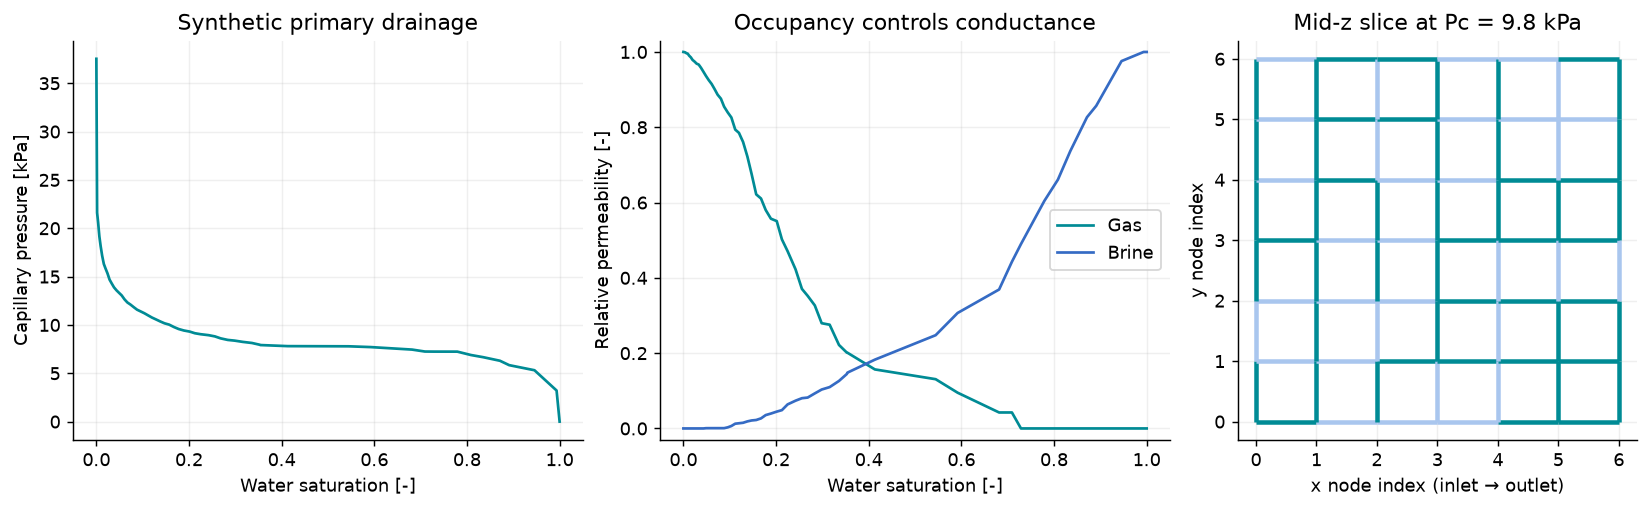

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout="constrained")
axes[0].plot(1 - drainage_base.Sg, drainage_base.Pc_Pa / 1000, color="#008b95")
axes[0].set(xlabel="Water saturation [-]", ylabel="Capillary pressure [kPa]",
            title="Synthetic primary drainage")
axes[1].plot(1 - drainage_base.Sg, drainage_base.krg, label="Gas", color="#008b95")
axes[1].plot(1 - drainage_base.Sg, drainage_base.krw, label="Brine", color="#356bc4")
axes[1].set(xlabel="Water saturation [-]", ylabel="Relative permeability [-]",
            title="Occupancy controls conductance", ylim=(-0.03, 1.03))
axes[1].legend()
coordinates = network["coordinates"]
edges = network["edges"]
slice_edges = (coordinates[edges[:, 0], 2] == 3) & (coordinates[edges[:, 1], 2] == 3)
view_pressure = float(drainage_base.iloc[len(drainage_base)//2].Pc_Pa)
segments = coordinates[edges[slice_edges], :2]
edge_colors = np.where(thresholds[slice_edges] <= view_pressure, "#008b95", "#a9c6ee")
axes[2].add_collection(LineCollection(segments, colors=edge_colors, linewidths=2.5))
axes[2].autoscale()
axes[2].set(xlabel="x node index (inlet → outlet)", ylabel="y node index",
            title=f"Mid-z slice at Pc = {view_pressure/1000:.1f} kPa")
axes[2].set_aspect("equal")
plt.show()

## 4. Wettability, interfacial tension and connectivity

**Synthetic inputs:** median throat radius 12 µm (clipped to 3–35 µm), 100 µm throat length, reference interfacial tension 65 mN/m, and water-wet angles. None of these is extracted from SPE-219290-MS.

Uniformly changing the contact angle or interfacial tension scales all entry pressures by the same factor. It preserves invasion order in this model, so it leaves $k_r(S)$ unchanged. A heterogeneous contact-angle field can change that order. This is a useful test of model scope: it does not establish the paper's reported directional wettability trend.

Uniform-angle invariance and interfacial-tension scaling checks passed.


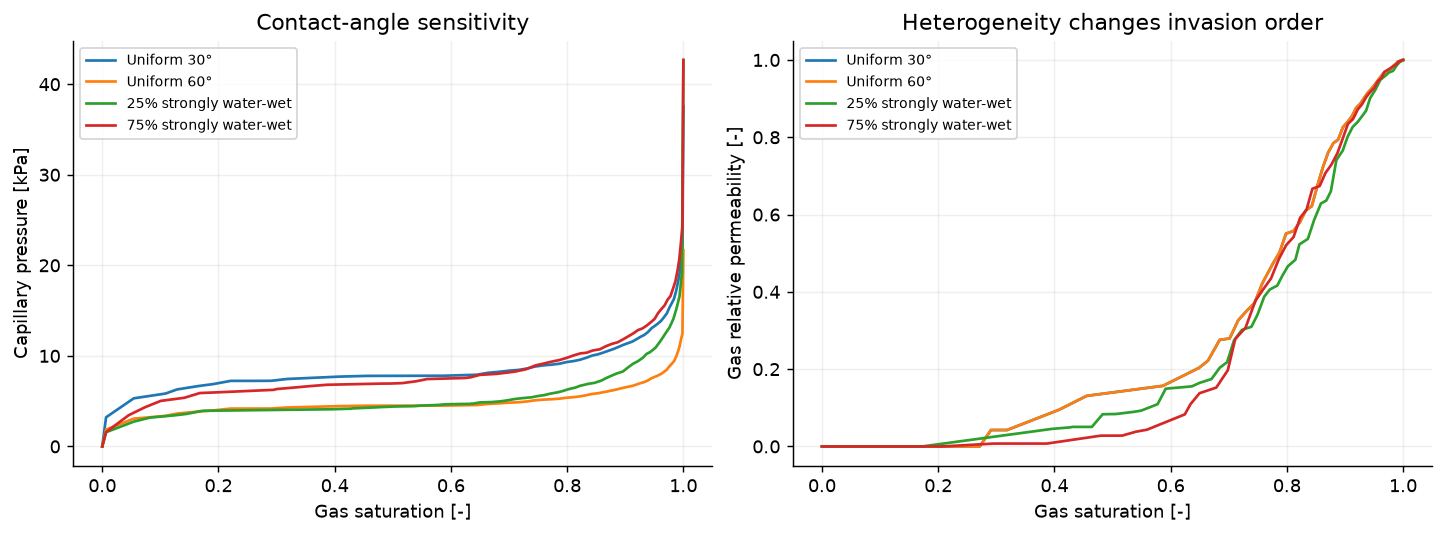

In [10]:
rng = np.random.default_rng(1734)
rank = rng.random(len(network["edges"]))
angle_fields = {
    "Uniform 30°": uniform_angles,
    "Uniform 60°": np.full(len(rank), 60.0),
    "25% strongly water-wet": np.where(rank < 0.25, 10.0, 65.0),
    "75% strongly water-wet": np.where(rank < 0.75, 10.0, 65.0),
}
wettability_results = {
    label: drainage(network, angles)[0] for label, angles in angle_fields.items()
}
assert np.allclose(wettability_results["Uniform 30°"].krg,
                   wettability_results["Uniform 60°"].krg, atol=1e-12)
ift_thresholds = invasion_thresholds(network, uniform_angles, sigma_N_m=0.080)
assert np.allclose(ift_thresholds / thresholds, 0.080 / 0.065, rtol=1e-12)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for label, curve in wettability_results.items():
    axes[0].plot(curve.Sg, curve.Pc_Pa / 1000, label=label)
    axes[1].plot(curve.Sg, curve.krg, label=label)
axes[0].set(xlabel="Gas saturation [-]", ylabel="Capillary pressure [kPa]",
            title="Contact-angle sensitivity")
axes[1].set(xlabel="Gas saturation [-]", ylabel="Gas relative permeability [-]",
            title="Heterogeneity changes invasion order")
for axis in axes:
    axis.legend(fontsize=8)
plt.show()
print("Uniform-angle invariance and interfacial-tension scaling checks passed.")

First flowing sampled saturation depends on pressure sampling, not residual trapping.


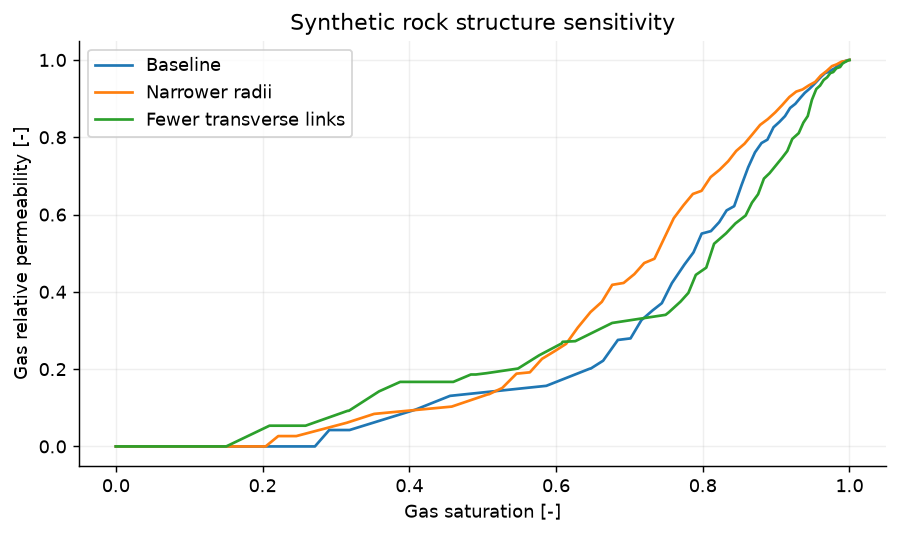

,case,throats,K_mD,first_sampled_flow_Sg
0,Baseline,882,1239.5312,0.2909
1,Narrower radii,882,986.5566,0.2213
2,Fewer transverse links,611,937.4898,0.2094


In [11]:
rock_cases = {
    "Baseline": network,
    "Narrower radii": make_network(radius_spread=0.25),
    "Fewer transverse links": make_network(transverse_retention=0.55),
}
rock_rows = []
fig, axis = plt.subplots(figsize=(6.8, 4), layout="constrained")
for label, rock in rock_cases.items():
    curve, _ = drainage(rock, np.full(len(rock["edges"]), 30.0))
    flow, _ = hydraulic_flow(rock, np.ones(len(rock["edges"]), dtype=bool))
    permeability = flow * rock["sample_length"] / rock["sample_area"]
    connected_gas = curve[curve.krg > 1e-10].iloc[0]
    rock_rows.append({"case": label, "throats": len(rock["edges"]),
                      "K_mD": permeability / 9.869233e-16,
                      "first_sampled_flow_Sg": connected_gas.Sg})
    axis.plot(curve.Sg, curve.krg, label=label)
axis.set(xlabel="Gas saturation [-]", ylabel="Gas relative permeability [-]",
         title="Synthetic rock structure sensitivity")
axis.legend()
plt.show()
display(pd.DataFrame(rock_rows).round(4))
print("First flowing sampled saturation depends on pressure sampling, not residual trapping.")

## 5. Use NeqSim's native Corey functions as a compact surrogate

The native `RelativePermeabilityGenerator` provides Corey/LET curves in oil–water and oil–gas table layouts. For this two-fluid mathematical fit, we use its `SWOF` curve generator and explicitly interpret the nonwetting curve `Krow` as gas. **We do not export that SWOF table as a gas–water simulator deck.** The output below is a clearly named gas–brine CSV.

We fit only the synthetic network curve. The exponents summarize this network and drainage history; they are not contact angles or fitted parameters from the paper.

$$S_w^*=\frac{S_w-S_{wc}}{1-S_{wc}-S_{gr}},\qquad k_{rw}=(S_w^*)^{n_w},\qquad k_{rg}=(1-S_w^*)^{n_g}$$

Here $S_{wc}=S_{gr}=0$ follows this simplified network's endpoints, and $n_w,n_g$ are dimensionless fitted exponents. A realistic residual-saturation model requires additional physics and data.

Fitted exponents: water 2.028, gas 2.819
Synthetic-network fit RMSE (dimensionless): 0.0419; not a paper error


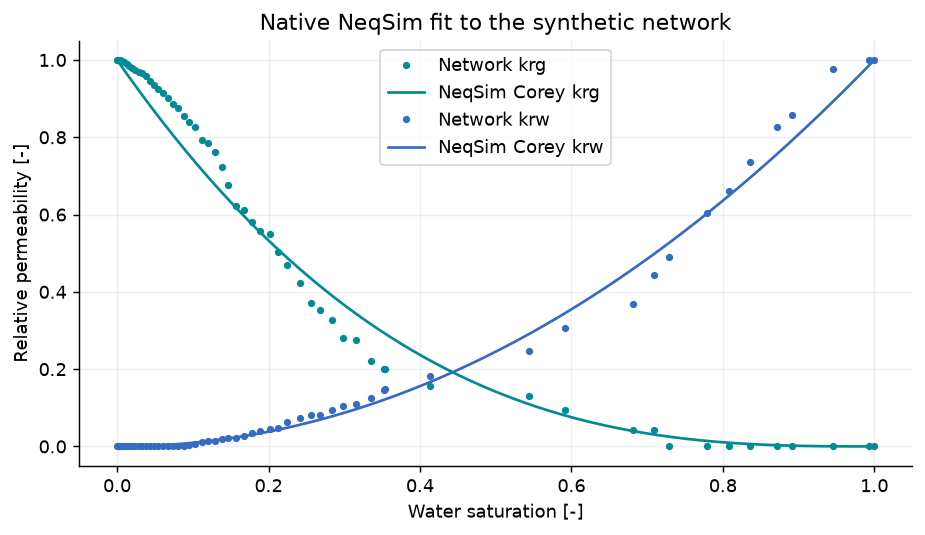

In [12]:
RelPerm = J.pvtsimulation.reservoirproperties.relpermeability

def native_corey(exponents):
    generator = RelPerm.RelativePermeabilityGenerator()
    generator.setTableType(RelPerm.RelPermTableType.SWOF)
    generator.setModelFamily(RelPerm.RelPermModelFamily.COREY)
    generator.setSwc(0.0)
    generator.setSwcr(0.0)
    generator.setSorw(0.0)
    generator.setKrwMax(1.0)
    generator.setKroMax(1.0)
    generator.setNw(float(exponents[0]))
    generator.setNo(float(exponents[1]))
    generator.setRows(201)
    table = generator.generate()
    return pd.DataFrame({
        "Sw": list(table.get("Sw")),
        "krw": list(table.get("Krw")),
        "krg": list(table.get("Krow")),
    })


def corey_residual(exponents):
    table = native_corey(exponents)
    water_saturation = 1 - drainage_base.Sg.to_numpy()
    return np.r_[
        np.interp(water_saturation, table.Sw, table.krw) - drainage_base.krw,
        np.interp(water_saturation, table.Sw, table.krg) - drainage_base.krg,
    ]


fit = least_squares(corey_residual, [3.0, 3.0], bounds=([0.1, 0.1], [15.0, 15.0]))
assert fit.success
corey_table = native_corey(fit.x)
corey_rmse = np.sqrt(np.mean(corey_residual(fit.x)**2))
print(f"Fitted exponents: water {fit.x[0]:.3f}, gas {fit.x[1]:.3f}")
print(f"Synthetic-network fit RMSE (dimensionless): {corey_rmse:.4f}; not a paper error")
fig, axis = plt.subplots(figsize=(7, 4), layout="constrained")
for column, color in [("krg", "#008b95"), ("krw", "#356bc4")]:
    axis.plot(1 - drainage_base.Sg, drainage_base[column], "o", ms=3,
              color=color, label=f"Network {column}")
    axis.plot(corey_table.Sw, corey_table[column], color=color, label=f"NeqSim Corey {column}")
axis.set(xlabel="Water saturation [-]", ylabel="Relative permeability [-]",
         title="Native NeqSim fit to the synthetic network")
axis.legend()
plt.show()

## 6. Similar relative permeability does not imply equal flow

Freeze the network geometry, occupancy and contact angles for all three gases. Relative permeability is then identical **by construction**; its viscosity cancels from the definition. The pressure-driven velocity differs:

$$u_\alpha=\frac{k\,k_{r,\alpha}}{\mu_\alpha}\frac{\Delta p}{L},\qquad f_g=\frac{k_{rg}/\mu_g}{k_{rg}/\mu_g+k_{rw}/\mu_w}$$

Here $u_\alpha$ is Darcy velocity in m/s, absolute permeability $k$ in m², imposed pressure gradient $\Delta p/L$ in Pa/m, and $f_g$ is dimensionless gas fractional flow. We neglect gravity in this horizontal pressure-driven calculation. A separate buoyancy pressure scale is $\Delta\rho gH$, in Pa, for a chosen vertical height $H$ in m.

These calculations explain why the paper's reported similarity between gas relative-permeability curves does not by itself establish equal injectivity, displacement or recovery. Actual gas-specific contact angles and interfacial tensions would also need measurement.

Velocity is a local synthetic Darcy screen, not a field injection-rate prediction.


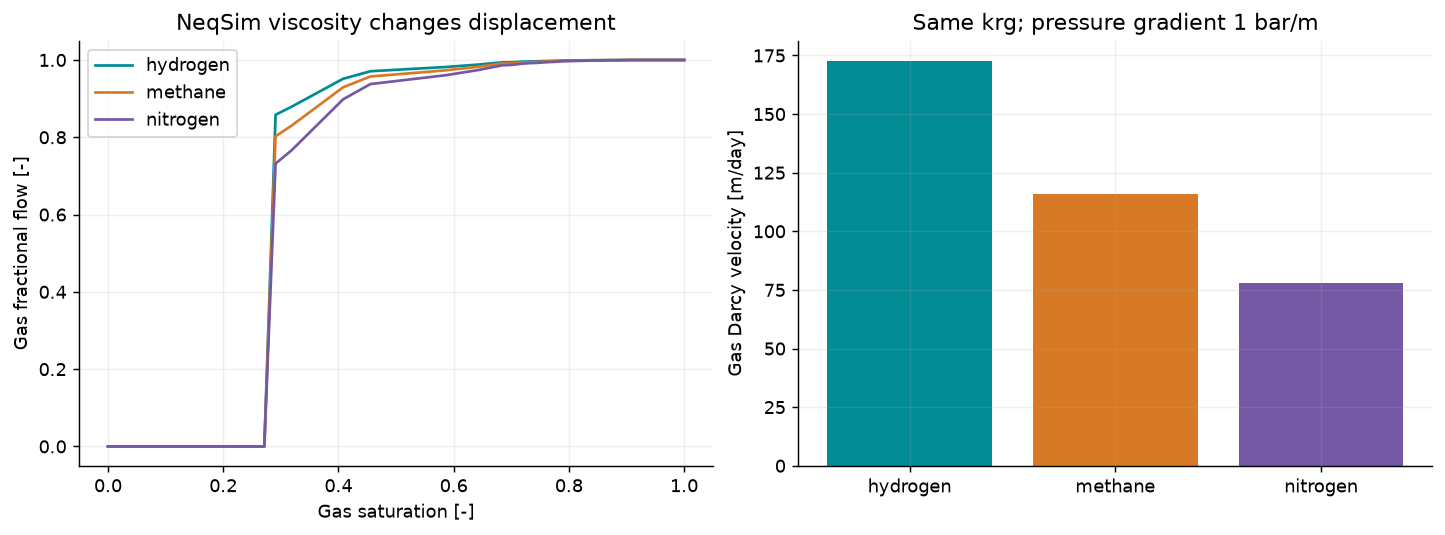

,gas,Sg,krg,Darcy_velocity_m_day,buoyancy_10m_kPa
0,hydrogen,0.58673,0.1568,172.68133,100.33124
1,methane,0.58673,0.1568,116.05725,94.57880
2,nitrogen,0.58673,0.1568,77.88803,91.06648


In [13]:
brine_reference = brine_properties.query("salt_mol_kg == 1").iloc[0]
mu_water = float(brine_reference.viscosity_Pa_s)
selected = drainage_base.iloc[np.argmin(abs(drainage_base.Sg.to_numpy() - 0.60))]
pressure_gradient = 1e5
height_m = 10.0
mobility_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for gas in GASES:
    mu_gas = gas_transport.loc[gas, "viscosity_uPa_s"] * 1e-6
    mobility_gas = drainage_base.krg / mu_gas
    mobility_water = drainage_base.krw / mu_water
    fractional_flow = mobility_gas / (mobility_gas + mobility_water)
    axes[0].plot(drainage_base.Sg, fractional_flow, color=COLORS[gas], label=gas)
    velocity = absolute_permeability * selected.krg / mu_gas * pressure_gradient
    buoyancy = (brine_reference.density_kg_m3 - gas_transport.loc[gas, "density_kg_m3"])
    buoyancy *= 9.80665 * height_m
    mobility_rows.append({
        "gas": gas,
        "Sg": selected.Sg,
        "krg": selected.krg,
        "Darcy_velocity_m_day": velocity * 86400,
        "buoyancy_10m_kPa": buoyancy / 1000,
    })
    full_phase_flow, _ = hydraulic_flow(network, all_open, viscosity=mu_gas)
    assert np.isclose(full_phase_flow * mu_gas / reference_flow, 1.0, rtol=1e-12)
mobility = pd.DataFrame(mobility_rows)
axes[0].set(xlabel="Gas saturation [-]", ylabel="Gas fractional flow [-]",
            title="NeqSim viscosity changes displacement")
axes[0].legend()
axes[1].bar(mobility.gas, mobility.Darcy_velocity_m_day, color=[COLORS[g] for g in GASES])
axes[1].set(ylabel="Gas Darcy velocity [m/day]", title="Same krg; pressure gradient 1 bar/m")
plt.show()
display(mobility.round(5))
print("Velocity is a local synthetic Darcy screen, not a field injection-rate prediction.")

## 7. Numerical sensitivity and what is actually compared

The finite network is one random realization, not a representative elementary volume established for a rock. Below we vary network size at fixed throat-length/radius statistics and repeat random seeds. This is a **size/realization sensitivity**, not mesh convergence to an experimental core. We separately refine capillary-pressure sampling on the same network.

In [14]:
sensitivity_rows = []
for size, seed in itertools.product([5, 7, 9], [3734, 3735, 3736]):
    rock = make_network(size=size, seed=seed)
    flow, flow_error = hydraulic_flow(rock, np.ones(len(rock["edges"]), dtype=bool))
    permeability = flow * rock["sample_length"] / rock["sample_area"]
    assert flow_error < 1e-9
    sensitivity_rows.append({"size": size, "seed": seed, "K_mD": permeability / 9.869233e-16})
size_sensitivity = pd.DataFrame(sensitivity_rows)
display(size_sensitivity.groupby("size").K_mD.agg(["mean", "min", "max"]).round(3))
fine_curve, _ = drainage(network, uniform_angles, samples=241)
common_saturations = np.linspace(0, 1, 101)
coarse = np.interp(common_saturations, drainage_base.Sg, drainage_base.krg)
fine = np.interp(common_saturations, fine_curve.Sg, fine_curve.krg)
sampling_error = float(np.max(abs(coarse - fine)))
print(f"Maximum interpolated krg change, 61 → 241 pressure quantiles: {sampling_error:.5f}")
print("Discrete invasion jumps are retained; saturation interpolation smooths those jumps.")

Maximum interpolated krg change, 61 → 241 pressure quantiles: 0.01431
Discrete invasion jumps are retained; saturation interpolation smooths those jumps.


,mean,min,max
size,,,
5,1437.450,1156.351,1797.166
7,1246.325,1231.708,1267.737
9,1256.212,1166.668,1424.150


### Comparison with Dorhjie and Cheremisin (2024)

The following source statements are paraphrases of the [publisher-indexed abstract](https://onepetro.org/SPEGOTS/proceedings-abstract/24GOTS/24GOTS/545223), accessed 16 September 2026. The notebook interpretations are our own.

| Reported in the paper's abstract | Notebook result / scope | Comparison status |
|---|---|---|
| Network and flow curves were checked against laboratory core characteristics | Synthetic network checked against an analytical resistor-network solution | Different validation target; no core reproduction |
| Contact-angle distributions affect capillary pressure and relative permeability | Heterogeneous angles change invasion ordering; uniform-angle scaling changes pressure only | Mechanism illustration; model limitation is visible |
| More strongly water-wet pores reduce hydrogen relative permeability | We do not impose or claim this directional trend; films and pore-body events are absent | Not validated |
| Geometry and connectivity influence residual saturation | Connectivity changes drainage conductance; no residual trapping is modeled | Residual-saturation finding not tested |
| CH4 and N2 relative permeabilities resemble hydrogen's | Frozen occupancy gives identical curves by construction; NeqSim viscosities produce different mobilities | Consistent conceptual explanation, not independent confirmation |

**To make a numerical paper comparison:** obtain the paper and supporting data with appropriate access; identify rock geometry/porosity/permeability, T/P/salinity, contact-angle distributions, interfacial tensions, displacement protocol and measured curves. Then use a pore-body/film/trapping model consistent with those methods, reserve independent data for validation, and report uncertainty and errors. No paper points have been invented here.

## 8. Findings, limitations and reusable outputs

- NeqSim supplies equilibrium and transport properties and an existing Corey representation. It does not infer rock wettability, throat geometry or trapping from a fluid composition.
- The network's invariant curves under uniform entry-pressure scaling are a useful guard against attributing every pressure change to a relative-permeability change.
- Hydrogen's different viscosity and density matter even when relative permeability is held fixed. Numerical results above depend on the stated dry-gas and empirical brine approximations.
- The Fürst hydrogen–brine case is unqualified and excluded from accepted downstream calculations; [#3736](https://github.com/equinor/neqsim/issues/3736) contains the source-pinned reproducer and acceptance criteria. Existing APIs suffice for the bounded SW/CPA/transport study, so no empirical model parameters were changed to force agreement.
- There is no quantitative validation against SPE-219290-MS, no cyclic recovery forecast, and no claim of site-specific storage performance. The main extension needed for that task is experimentally qualified pore-body, film, trapping and hysteresis physics.

**Exercises:** replace synthetic rock inputs with measured ones; compare fixed flow rate and fixed pressure gradient; supply measured gas-specific contact angles and interfacial tensions; evaluate whether Corey or LET captures a qualified network; add a separate imbibition model with documented trapping rules.

**References and provenance**

1. Dorhjie, D. B. and Cheremisin, A. (2024), SPE-219290-MS, [DOI](https://doi.org/10.2118/219290-MS). Abstract-level source access only; copyrighted paper figures/tables are not redistributed.
2. [NeqSim Søreide–Whitson guide](https://github.com/equinor/neqsim/blob/87f3c41266ed6ce6dc4ec3879411ae7da59b5eca/docs/thermo/SoreideWhitsonModel.md), including Burgoyne–Nielsen (2026) parameter provenance and limitations.
3. [NeqSim electrolyte CPA guide](https://github.com/equinor/neqsim/blob/87f3c41266ed6ce6dc4ec3879411ae7da59b5eca/docs/thermo/ElectrolyteCPAModel.md).
4. [NeqSim relative-permeability guide](https://github.com/equinor/neqsim/blob/87f3c41266ed6ce6dc4ec3879411ae7da59b5eca/docs/pvtsimulation/relative_permeability.md).
5. Transport correlations and citations are retained in NeqSim's `MuznyViscosityMethod`, liquid `Water` viscosity/density classes and `SaltWaterPhysicalProperties`.

All network geometry and resulting curves in this notebook are generated from the displayed synthetic definitions and random seeds. CSV exports use explicit units and phase names and contain no extracted paper data.

In [15]:
exports = {
    "neqsim_equilibrium.csv": flash_results,
    "dry_gas_transport.csv": gas_transport.reset_index(),
    "brine_transport.csv": brine_properties,
    "electrolyte_diagnostic_only.csv": audit,
    "synthetic_network_drainage.csv": drainage_base,
    "synthetic_network_drainage_fine.csv": fine_curve,
    "native_corey_gas_brine.csv": corey_table,
    "synthetic_mobility.csv": mobility,
    "size_realization_sensitivity.csv": size_sensitivity,
    "validation.csv": validation,
}
for filename, table in exports.items():
    table.to_csv(results_directory / filename, index=False)
provenance["paper_comparison"] = "Qualitative abstract-level; no numerical reproduction"
provenance["synthetic_corey_rmse"] = float(corey_rmse)
provenance["pressure_sampling_max_krg_difference"] = sampling_error
(results_directory / "provenance.json").write_text(json.dumps(provenance, indent=2))
print(f"Saved {len(exports)} CSV tables and provenance.json to {results_directory.resolve()}")
print("Accepted physical and numerical checks:", bool(validation['pass'].all()))
hydrogen_velocity = float(mobility.loc[mobility.gas == "hydrogen", "Darcy_velocity_m_day"].iloc[0])
nitrogen_velocity = float(mobility.loc[mobility.gas == "nitrogen", "Darcy_velocity_m_day"].iloc[0])
display(Markdown(
    f"**Calculated takeaway:** at the same synthetic gas occupancy and pressure gradient, "
    f"hydrogen's Darcy velocity is **{hydrogen_velocity / nitrogen_velocity:.2f} times** "
    f"nitrogen's, using the selected NeqSim viscosities. The network's analytical flow "
    f"check has relative error **{analytical_error:.2e}**. "
    "This is a transparent mechanism comparison, not a reproduction of the paper."
))
print("Paper numerical validation: not performed; full text/data unavailable.")
print("NeqSim follow-up: https://github.com/equinor/neqsim/issues/3736")

Saved 10 CSV tables and provenance.json to /workspace/scratch/ae2708680125/hydrogen_brine_results
Accepted physical and numerical checks: True
Paper numerical validation: not performed; full text/data unavailable.
NeqSim follow-up: https://github.com/equinor/neqsim/issues/3736


**Calculated takeaway:** at the same synthetic gas occupancy and pressure gradient, hydrogen's Darcy velocity is **2.22 times** nitrogen's, using the selected NeqSim viscosities. The network's analytical flow check has relative error **3.33e-16**. This is a transparent mechanism comparison, not a reproduction of the paper.